In [8]:
from shadow_service import ShadowService

import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
max_lat = 52.1600
min_lon = 11.5798
min_lat = 52.1187
max_lon = 11.7072

bbox = (min_lon, min_lat, max_lon, max_lat)

shadow_service = ShadowService(bbox, "./data/buildings_campus_sp_simplified.fgb")

In [3]:
dt = pd.to_datetime('2026-05-05 10:24').tz_localize('Europe/Berlin')
shadow_map = shadow_service.get_shadow_map(dt)

In [6]:
def plot_shadows_and_buildings(buildings: gpd.GeoDataFrame, shadows: gpd.GeoDataFrame, dt: pd.Timestamp, whole_day=False):
    fig, ax = plt.subplots(figsize=(12, 12))

    # --- Plot shadows ---
    if len(shadows) > 0:
        shadows.plot(ax=ax, color="#555555", alpha=0.4)

    # --- Plot buildings ---
    buildings.plot(
        ax=ax,
        color="#3a86ff",
        alpha=0.8,
        edgecolor="white",
        linewidth=0.5,
    )

    # --- Legend ---
    legend_handles = [
        mpatches.Patch(color="#3a86ff", alpha=0.8, label="Buildings"),
        mpatches.Patch(color="#555555", alpha=0.4, label="Ground Shadow"),
    ]

    ax.legend(handles=legend_handles, loc="upper right")

    ax.set_title(f"Building Shadow {dt.strftime('%Y-%m-%d %H:%M')}", fontsize=14)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    plt.tight_layout()

    plt.show()

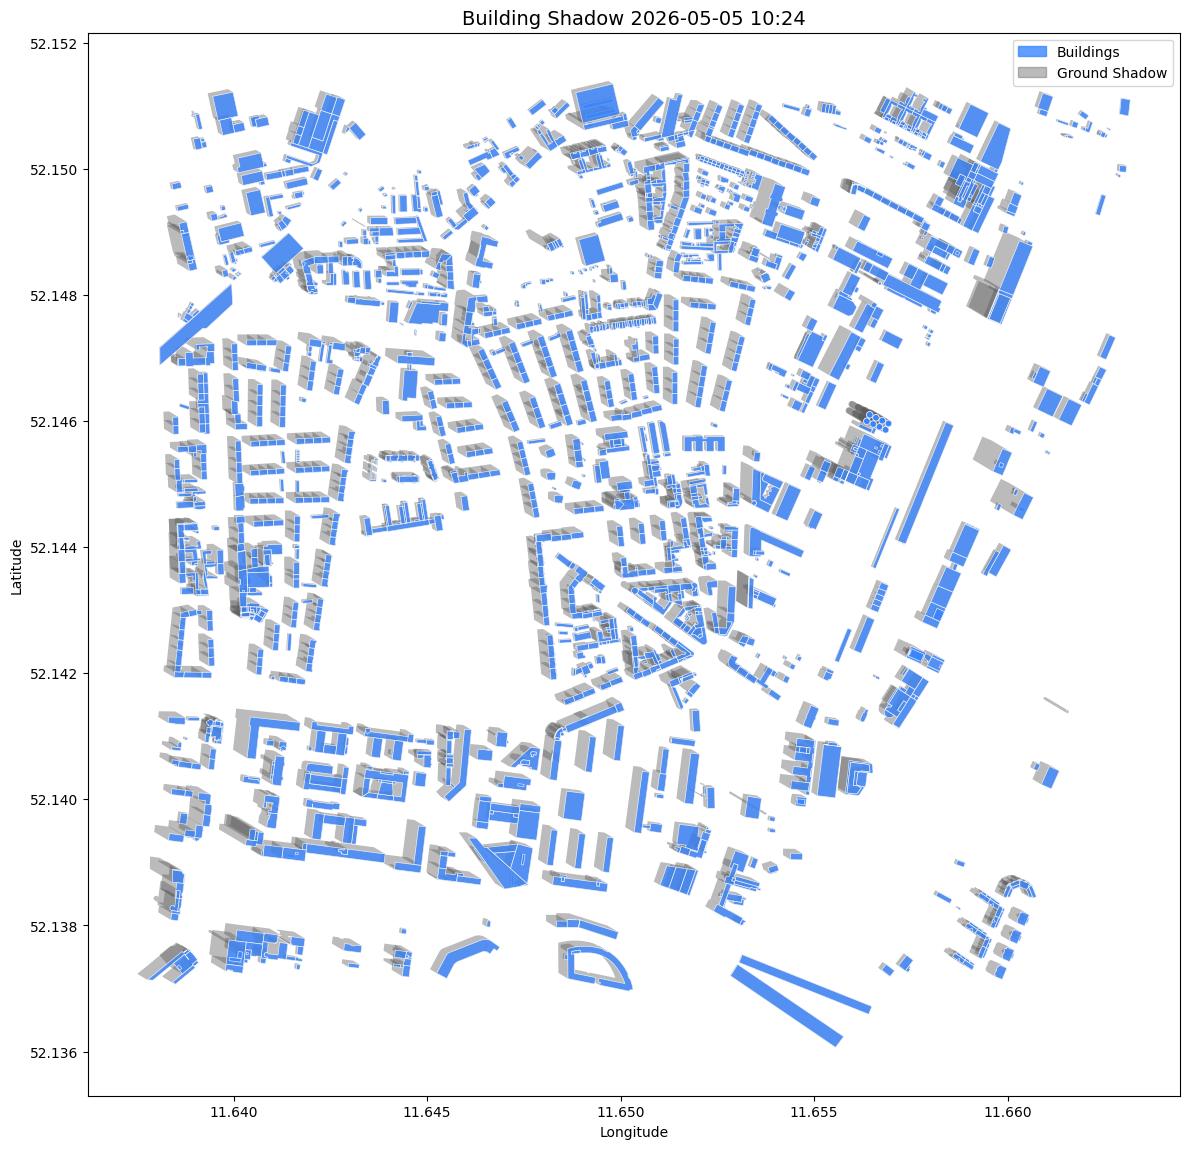

In [9]:
plot_shadows_and_buildings(shadow_service.buildings, shadow_map, dt)

In [10]:
shadow_map.to_parquet("shadows_map.parquet")

In [15]:
shadow_map_clean = shadow_map.drop(columns=["height", "type"])
shadow_map_clean.to_parquet("shadows_map.parquet")